In [118]:
import tensorflow as tf
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [119]:
def visualize_input(image, ax):
    ax.imshow(image, cmap='gray')
    width, height = image.shape
    thresh = image.max() / 2.5
    for x in range(width):
        for y in range(height):
            ax.annotate(str(image[x][y]), xy=(y, x),
                        horizontalalignment='center',
                        verticalalignment='center',
                        color='white' if image[y][x] < thresh else 'black')

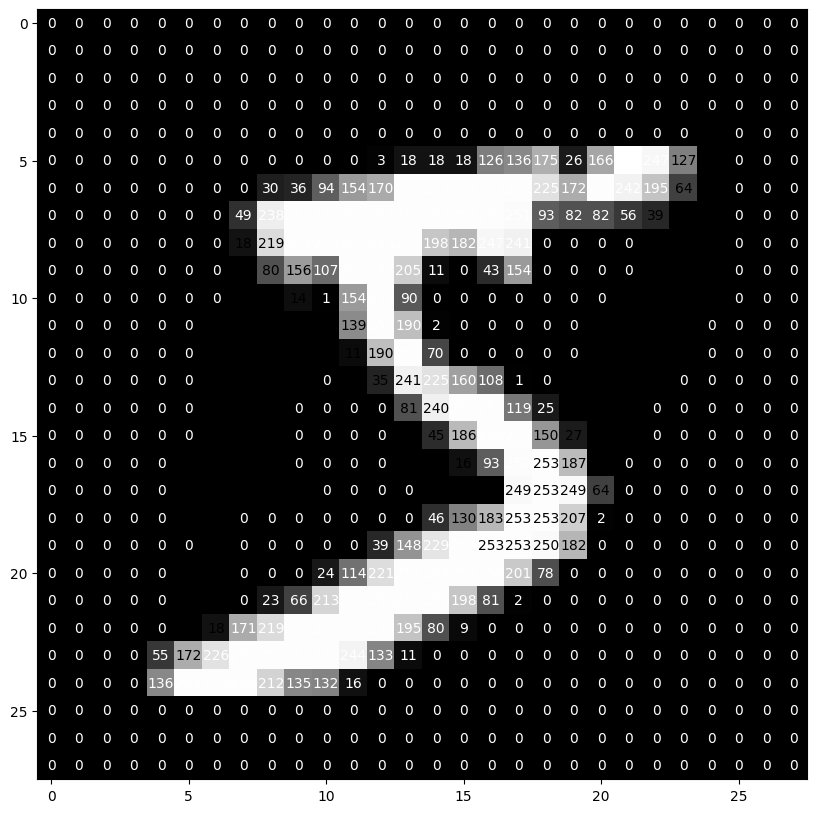

In [120]:
import matplotlib.pyplot as plt
fig =plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
visualize_input(x_train[0], ax)

Text(0.5, 1.0, '[np.uint8(5)]')

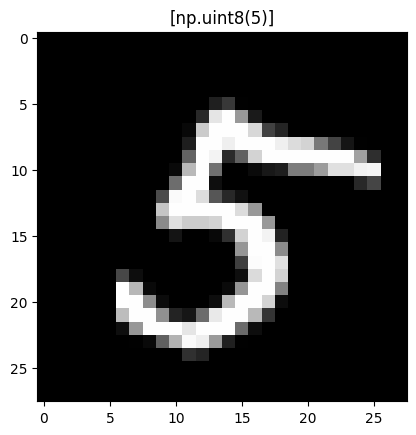

In [121]:
import random
import matplotlib.pyplot as plt
i = random.randint(0,60000)
plt.imshow(x_train[i],cmap='gray')
plt.title([y_train[i]])

In [122]:
import numpy as np
np.unique(y_train,return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([5923, 6742, 5958, 6131, 5842, 5421, 5918, 6265, 5851, 5949]))

In [123]:
np.unique(y_test,return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([ 980, 1135, 1032, 1010,  982,  892,  958, 1028,  974, 1009]))

In [124]:
x_train=x_train/255.0
x_test=x_test/255.0

print(x_train.max())
print(x_train.min())

1.0
0.0


In [125]:
from keras.layers import Dense, Flatten
model=tf.keras.models.Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(128,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(10,activation='softmax'))

model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
history=model.fit(x_train,y_train,epochs=10,validation_split=0.2)

c:\Users\shackelten\Web-app\venv\lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9224 - loss: 0.2658 - val_accuracy: 0.9567 - val_loss: 0.1440
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9665 - loss: 0.1121 - val_accuracy: 0.9701 - val_loss: 0.1006
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9760 - loss: 0.0774 - val_accuracy: 0.9702 - val_loss: 0.0982
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9819 - loss: 0.0584 - val_accuracy: 0.9712 - val_loss: 0.1021
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9846 - loss: 0.0480 - val_accuracy: 0.9725 - val_loss: 0.0997
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9880 - loss: 0.0370 - val_accuracy: 0.9744 - val_loss: 0.0987
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9892 - loss: 0.0319 - val_accuracy: 0.9717 - val_loss: 0.1033
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9910 - loss: 0.0262 - 

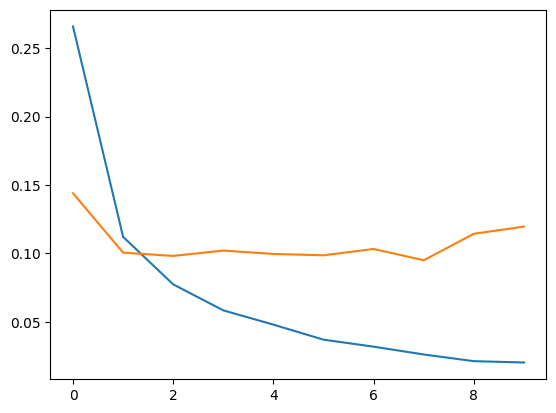

In [126]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

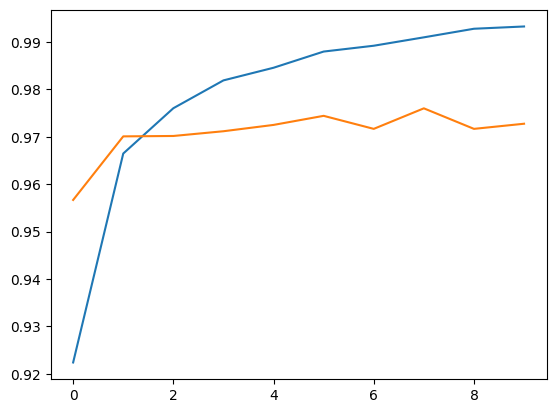

In [127]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step


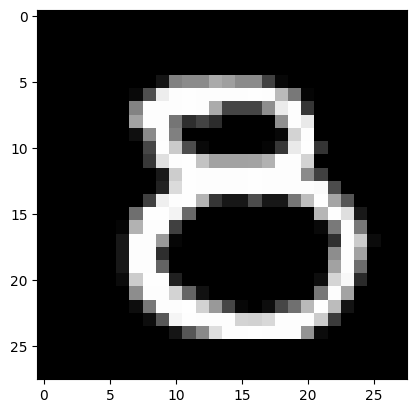

In [128]:
import keras.utils as image

img=image.load_img(path='8.png',color_mode='grayscale',target_size=(28,28))
img=image.img_to_array(img)
plt.imshow(img[:,:,0],cmap='gray')
img=img.astype('float') / 255.0
test_image=img.reshape(1,28,28)
#img_class = model.predict_classes(test_img)
img_class = np.argmax(model.predict(test_image), axis = 1)
prediction=img_class[0]

In [129]:
prediction

np.int64(8)

In [130]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

y_pred = model.predict(x_test)
y_pred = np.argmax(y_pred,axis=1)
accuracy_score(y_pred,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


0.9756

In [131]:
confusion_matrix(y_pred,y_test)

array([[ 975,    0,    3,    0,    3,    3,    5,    1,    4,    4],
       [   0, 1122,    0,    0,    0,    0,    2,    4,    1,    3],
       [   0,    5, 1014,   11,    3,    0,    1,   13,    6,    2],
       [   2,    1,    0,  965,    0,   10,    0,    2,    2,    1],
       [   0,    0,    2,    0,  953,    0,    1,    1,    1,    8],
       [   0,    0,    1,   11,    0,  864,    5,    0,    6,    4],
       [   2,    2,    4,    0,    6,    8,  944,    1,    3,    0],
       [   1,    1,    4,    2,    4,    2,    0,  998,    3,    8],
       [   0,    4,    4,    7,    0,    4,    0,    0,  943,    1],
       [   0,    0,    0,   14,   13,    1,    0,    8,    5,  978]])

In [132]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.99      0.98      0.99       998
           1       0.99      0.99      0.99      1132
           2       0.98      0.96      0.97      1055
           3       0.96      0.98      0.97       983
           4       0.97      0.99      0.98       966
           5       0.97      0.97      0.97       891
           6       0.99      0.97      0.98       970
           7       0.97      0.98      0.97      1023
           8       0.97      0.98      0.97       963
           9       0.97      0.96      0.96      1019

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000



In [133]:
model.save("mnist.keras")